In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces
from pathlib import Path

In [2]:
# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.98
batch_size = 64
learning_rate = 1e-3
num_seconds=3600
episodes = 100

In [3]:
base = Path("env_iiser") / "new"

route_files = [
    base / "vtypes.add.xml",
    base / "cars.rou.xml",
    base / "buses.rou.xml",
    base / "bikes.rou.xml",
    base / "ambulance.rou.xml",
]

net_path = str(base / "map.net.xml")
route = ",".join(str(p) for p in route_files)

In [4]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [5]:
def priority_reward_fn(ts):
    """
    Custom reward function that heavily penalizes stopped ambulances and buses.
    ts: The TrafficSignal object provided by sumo_rl.
    """
    reward = 0
    # Access the TraCI connection directly through the traffic signal
    traci = ts.sumo 
    
    # Iterate through all incoming lanes controlled by this specific traffic light
    for lane in ts.lanes:
        # Get the IDs of all vehicles currently on this lane
        vehicles = traci.lane.getLastStepVehicleIDs(lane)
        
        for veh in vehicles:
            # Get the vehicle's current speed
            speed = traci.vehicle.getSpeed(veh)
            
            # If the vehicle is practically stopped (waiting at a red light)
            if speed < 0.1:
                # Retrieve the vehicle type (defined in our .rou.xml file)
                v_type = traci.vehicle.getTypeID(veh)
                
                # Apply custom penalty weights
                if v_type == "ambulance":
                    reward -= 50.0  # Massive penalty for delaying an ambulance
                elif v_type == "bus":
                    reward -= 5.0   # Moderate penalty for delaying a bus
                else:
                    reward -= 1.0   # Standard penalty for normal cars
                    
    return reward

In [6]:
class PriorityObservationFunction(ObservationFunction):
    def __init__(self, ts):
        super().__init__(ts)
        # We need to define the shape of our observation array.
        # Let's say: [density_N, density_S, density_E, density_W, emergency_present_N, emergency_present_S...]
        pass 

    def __call__(self):

        traci = self.ts.sumo
        obs = []
        
        # normal traffic density
        density = self.ts.get_lanes_density()
        obs.extend(density)
        
        # whether an ambulance is waiting on each lane
        for lane in self.ts.lanes:
            emergency_waiting = 0.0
            vehicles = traci.lane.getLastStepVehicleIDs(lane)
            for veh in vehicles:
                if traci.vehicle.getTypeID(veh) == "ambulance":
                    emergency_waiting = 1.0
                    break
            obs.append(emergency_waiting)
            
        return np.array(obs, dtype=np.float32)

    def observation_space(self):
        return spaces.Box(low=0., high=1., shape=(len(self.ts.lanes) * 2,), dtype=np.float32)

In [7]:
def evaluate_model():
    
    env = sumo_rl.parallel_env(
        net_file = net_path,
        route_file = route,
        use_gui=False,
        num_seconds=1800,   
        delta_time=5,
        observation_class=PriorityObservationFunction,
        reward_fn=priority_reward_fn,
        additional_sumo_cmd="--tripinfo-output results/rl_tripinfo.xml"
    )

    # Re-initialize and load models for each agent
    eval_q_nets = {}
    for agent in env.possible_agents:
        obs_dim = env.observation_space(agent).shape[0]
        action_dim = env.action_space(agent).n
        eval_q_nets[agent] = QNetwork(obs_dim, action_dim)
        
        try:
            eval_q_nets[agent].load_state_dict(torch.load(str(Path("models") / "iiser_priority" / f"{agent}.pth" )))
            eval_q_nets[agent].eval()
        except FileNotFoundError:
            print(f"Error: Could not find the model for {agent}.")
            return

    print("Models loaded successfully!")

    # Run the Simulation Loop
    observations, infos = env.reset()
    total_evaluation_reward = 0
    
    while env.agents:
        actions = {}
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            with torch.no_grad():
                q_values = eval_q_nets[agent](obs_tensor)
                actions[agent] = torch.argmax(q_values).item() 

        observations, rewards, terminations, truncations, infos = env.step(actions)

        for agent in env.agents:
            total_evaluation_reward += rewards[agent]

    print(f"Simulation Finished. Final Total Reward: {total_evaluation_reward:.2f}")
    env.close()

In [8]:
evaluate_model()

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 45ms, vehicles TOT 0 ACT 0 BUF 0)                     
Models loaded successfully!
 Retrying in 1 seconds


Simulation Finished. Final Total Reward: -1427.00
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 78ms, vehicles TOT 179 ACT 25 BUF 0)                


In [12]:
import traci

def evaluate_baseline():
    print("Running Baseline (Fixed-Time) Simulation...")
    
    # Start SUMO directly (No sumo_rl wrapper)
    sumo_cmd = [
        "sumo", # Use "sumo-gui" if you want to watch it visually
        "-n", net_path,
        "-r", route, # Make sure this variable holds your route files
        "--step-length", "5",
        "--tripinfo-output", "results/baseline_tripinfo.xml", # <-- Save baseline metrics
        "-W"
    ]
    
    traci.start(sumo_cmd)
    
    # Run the simulation until all cars have left or we hit 1800 seconds
    step = 0
    while traci.simulation.getMinExpectedNumber() > 0 and step < 1800:
        traci.simulationStep()
        step += 5
        
    traci.close()
    print("Baseline Simulation Finished!")

evaluate_baseline()

Running Baseline (Fixed-Time) Simulation...
 Retrying in 1 seconds
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 179 ACT 37 BUF 0)                 
Baseline Simulation Finished!


In [13]:
act_path = "./env_iiser/new/map_actuated.net.xml"

def evaluate_baseline():
    print("Running Baseline (Fixed-Time) Simulation...")
    
    # Start SUMO directly (No sumo_rl wrapper)
    sumo_cmd = [
        "sumo", # Use "sumo-gui" if you want to watch it visually
        "-n", act_path,
        "-r", route, # Make sure this variable holds your route files
        "--step-length", "5",
        "--tripinfo-output", "results/actuated_tripinfo.xml", # <-- Save baseline metrics
        "-W"
    ]
    
    traci.start(sumo_cmd)
    
    # Run the simulation until all cars have left or we hit 1800 seconds
    step = 0
    while traci.simulation.getMinExpectedNumber() > 0 and step < 1800:
        traci.simulationStep()
        step += 5
        
    traci.close()
    print("Baseline Simulation Finished!")

evaluate_baseline()

Running Baseline (Fixed-Time) Simulation...
 Retrying in 1 seconds
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 179 ACT 29 BUF 0)                 
Baseline Simulation Finished!


In [19]:
def run_random_baseline():
    print("Running Random Agent Baseline...")
    
    # Use your original network and route files
    env = sumo_rl.parallel_env(
        net_file=net_path,
        route_file=route,
        use_gui=False,
        num_seconds=1800,
        delta_time=5,
        additional_sumo_cmd="--tripinfo-output results/random_tripinfo.xml"
    )

    observations, infos = env.reset()
    total_random_reward = 0
    
    while env.agents:
        actions = {}
        for agent in env.agents:
            # Randomly sample an action from the available action space
            actions[agent] = env.action_space(agent).sample()

        observations, rewards, terminations, truncations, infos = env.step(actions)

        for agent in rewards:
            total_random_reward += rewards[agent]

    print(f"Random Simulation Finished. Total Reward: {total_random_reward:.2f}")
    env.close()

run_random_baseline()

Running Random Agent Baseline...
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 45ms, vehicles TOT 0 ACT 0 BUF 0)                     
 Retrying in 1 seconds


Random Simulation Finished. Total Reward: -2.99
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 61ms, vehicles TOT 179 ACT 19 BUF 0)                


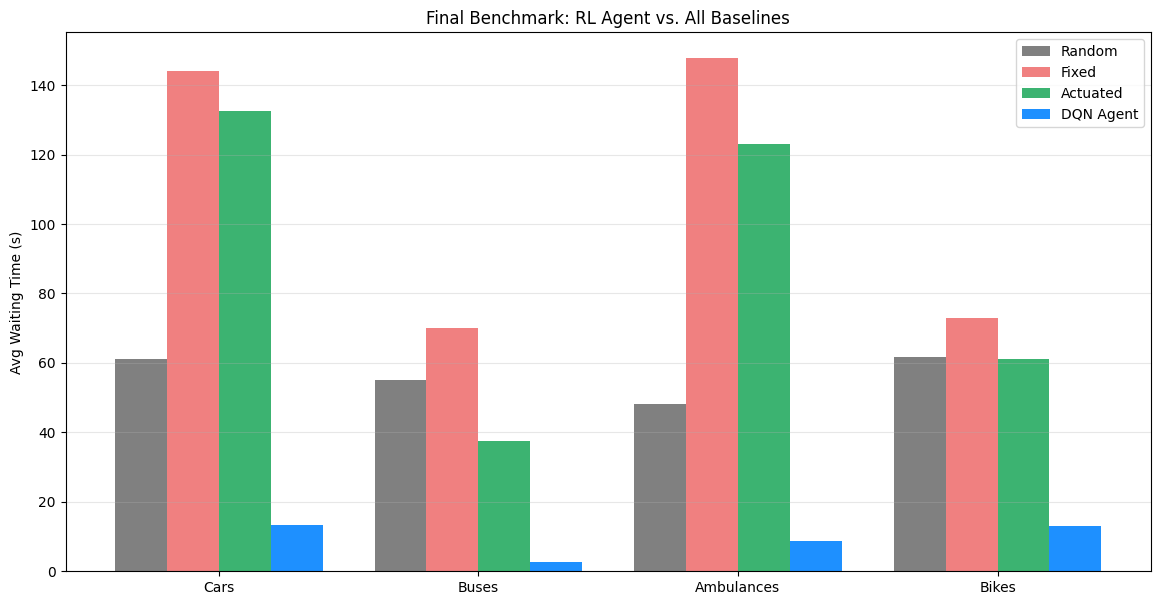

In [20]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

def analyze_tripinfo(file_path):
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
    except Exception:
        return {k: 0 for k in ['my_car', 'my_bus', 'my_emergency', 'my_bike']}
    
    wait_times = {'my_car': [], 'my_bus': [], 'my_emergency': [], 'my_bike': []}
    for trip in root.findall('tripinfo'):
        v_type = trip.get('vType')
        if v_type in wait_times:
            wait_times[v_type].append(float(trip.get('waitingTime')))
            
    return {v: (sum(t)/len(t) if t else 0) for v, t in wait_times.items()}

# Parse all four results
rl_metrics = analyze_tripinfo('results/rl_tripinfo.xml')
fixed_metrics = analyze_tripinfo('results/baseline_tripinfo.xml')
actuated_metrics = analyze_tripinfo('results/actuated_tripinfo.xml')
random_metrics = analyze_tripinfo('results/random_tripinfo.xml')

labels = ['Cars', 'Buses', 'Ambulances', 'Bikes']
keys = ['my_car', 'my_bus', 'my_emergency', 'my_bike']

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - 1.5*width, [random_metrics[k] for k in keys], width, label='Random', color='gray')
ax.bar(x - 0.5*width, [fixed_metrics[k] for k in keys], width, label='Fixed', color='lightcoral')
ax.bar(x + 0.5*width, [actuated_metrics[k] for k in keys], width, label='Actuated', color='mediumseagreen')
ax.bar(x + 1.5*width, [rl_metrics[k] for k in keys], width, label='DQN Agent', color='dodgerblue')

ax.set_ylabel('Avg Waiting Time (s)')
ax.set_title('Final Benchmark: RL Agent vs. All Baselines')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.grid(axis='y', alpha=0.3)
plt.show()

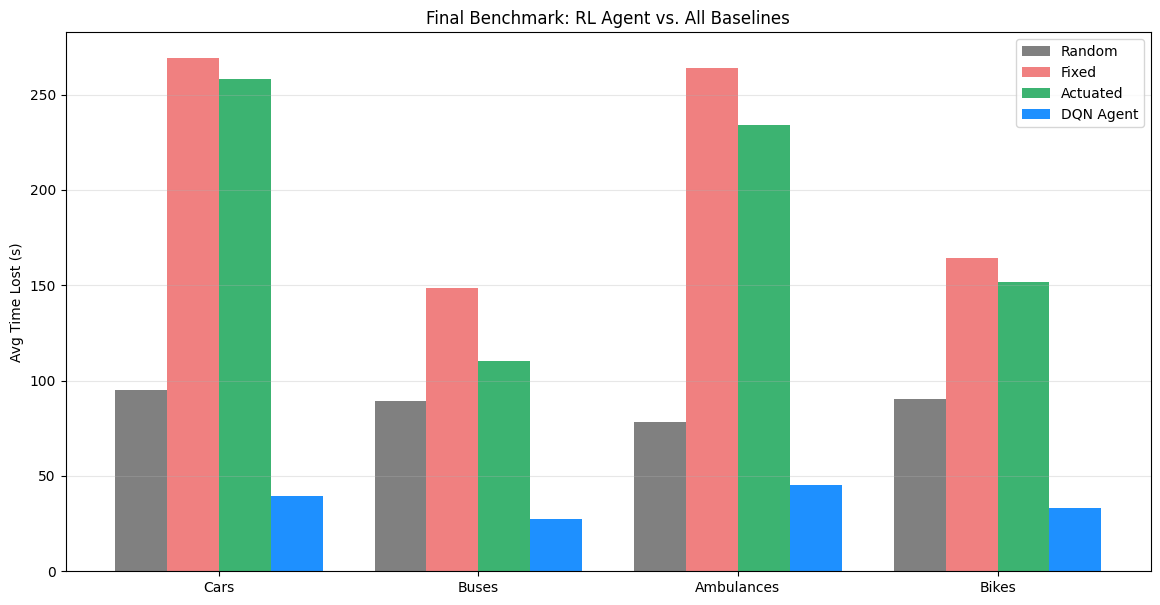

In [21]:
def analyze_tripinfo(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    # We switch to timeLoss for a fairer comparison
    metrics = {'my_car': [], 'my_bus': [], 'my_emergency': [], 'my_bike': []}
    
    for trip in root.findall('tripinfo'):
        v_type = trip.get('vType')
        # timeLoss is the total time lost due to driving slower than desired
        time_lost = float(trip.get('timeLoss')) 
        
        if v_type in metrics:
            metrics[v_type].append(time_lost)
            
    avg_metrics = {
        v: (sum(times)/len(times) if len(times) > 0 else 0) 
        for v, times in metrics.items()
    }
    return avg_metrics

# Parse all four results
rl_metrics = analyze_tripinfo('results/rl_tripinfo.xml')
fixed_metrics = analyze_tripinfo('results/baseline_tripinfo.xml')
actuated_metrics = analyze_tripinfo('results/actuated_tripinfo.xml')
random_metrics = analyze_tripinfo('results/random_tripinfo.xml')

labels = ['Cars', 'Buses', 'Ambulances', 'Bikes']
keys = ['my_car', 'my_bus', 'my_emergency', 'my_bike']

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - 1.5*width, [random_metrics[k] for k in keys], width, label='Random', color='gray')
ax.bar(x - 0.5*width, [fixed_metrics[k] for k in keys], width, label='Fixed', color='lightcoral')
ax.bar(x + 0.5*width, [actuated_metrics[k] for k in keys], width, label='Actuated', color='mediumseagreen')
ax.bar(x + 1.5*width, [rl_metrics[k] for k in keys], width, label='DQN Agent', color='dodgerblue')

ax.set_ylabel('Avg Time Lost (s)')
ax.set_title('Final Benchmark: RL Agent vs. All Baselines')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.savefig('benchmark.png')
plt.grid(axis='y', alpha=0.3)
plt.show()